Vocabulary Size: 7011
Max Sequence Length: 41


Model: "student_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_input (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 40, 200)        │     1,402,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 256)            │       467,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7011)           │     1,801,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,671,995 (14.01 MB)

 Trainable params: 3,671,995 (14.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.0479 - loss: 7.6686 - val_accuracy: 0.0532 - val_loss: 7.4625 - learning_rate: 0.0010
Epoch 2/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0669 - loss: 6.8881 - val_accuracy: 0.0710 - val_loss: 7.5282 - learning_rate: 0.0010
Epoch 3/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0846 - loss: 6.5050
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
662/662 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.0846 - loss: 6.5051 - val_accuracy: 0.0806 - val_loss: 7.6301 - learning_rate: 0.0010
Epoch 4/50
662/662 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1020 - loss: 5.9749 - val_accuracy: 0.0804 - val_loss: 7.8475 - learning_rate: 2.0000e-04
Epoch 5/50
658/662 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1122 - loss: 5.6599
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
662/662 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1122 - loss:

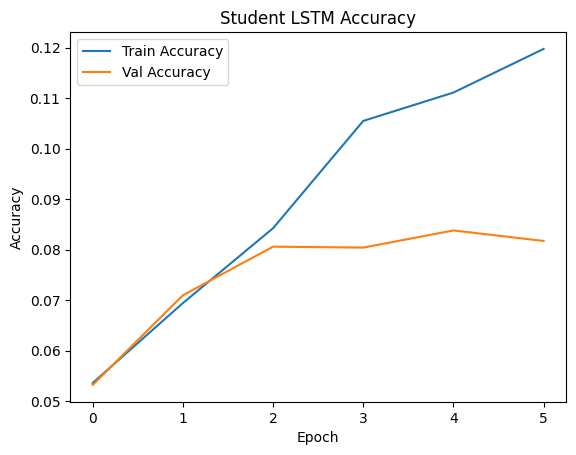


Example Prediction:
house is a of


In [ ]:
# ==============================================
# STUDENT LSTM ONLY (NO DISTILLATION)
# SAME PARAMETERS AS YOUR NOTEBOOK
# ==============================================

import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================
# 1. Data Loading

# =========================
data_path = "ArticlesMarch2018.csv"   # <-- same as notebook
df = pd.read_csv(data_path)
df['snippet'] = df['snippet'].astype(str)

# =========================
# 2. Text Cleaning (SAME AS NOTEBOOK)
# =========================
formatted_text = "\n".join(df['snippet'].tolist())
translator = str.maketrans('', '', string.punctuation)
formatted_text = formatted_text.translate(translator).lower()

# =========================
# 3. Tokenization
# =========================
tokenizer = Tokenizer()
tokenizer.fit_on_texts([formatted_text])
voc = len(tokenizer.word_index) + 1

# =========================
# 4. Sequence Creation
# =========================
input_sequences = []

for line in formatted_text.split('\n'):
    seq = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(seq)):
        input_sequences.append(seq[:i+1])

max_len = max(len(s) for s in input_sequences)

padded = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = padded[:, :-1]
y = to_categorical(padded[:, -1], num_classes=voc)

print("Vocabulary Size:", voc)
print("Max Sequence Length:", max_len)

# =========================
# 5. Callbacks (SAME AS NOTEBOOK)
# =========================
rlrong = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

estop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# =========================
# 6. Build Student LSTM
# =========================
inp = Input(shape=(max_len-1,), name="student_input")

x = Embedding(voc, 200)(inp)      # SAME embedding size
x = LSTM(256)(x)                  # SAME LSTM units
x = Dropout(0.2)(x)               # SAME dropout
out = Dense(voc, activation='softmax')(x)

model = Model(inp, out, name="student_lstm")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 7. Train
# =========================
history = model.fit(
    X, y,
    epochs=50,
    validation_split=0.2,
    callbacks=[rlrong, estop],
    verbose=1
)

# =========================
# 8. Plot Accuracy
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Student LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# =========================
# 9. Next Word Prediction Function
# =========================
def predict_next_word(seed_text, next_words=1):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


# Example
print("\nExample Prediction:")
print(predict_next_word("house is", 2))
